# 05 — Poređenje metoda i zaključci


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

import ast

## Učitavanje sačuvanih rezultata

In [15]:
kolone = ['dataset', 'model', 'method', 'mean_score', 'std_score',
          'n_evaluations', 'mean_time_sec', 'best_params']
rezultati = pd.read_csv('./results/all_results.csv', names=kolone)
rezultati

,dataset,model,method,mean_score,std_score,n_evaluations,mean_time_sec,best_params
0,breast_cancer,svm,grid_search,0.977582,0.003642,25,0.321243,"{'C': 10, 'gamma': 0.01}"
1,breast_cancer,random_forest,grid_search,0.961971,0.002412,60,12.501379,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
2,digits,svm,grid_search,0.990814,0.002106,25,1.946793,"{'C': 1, 'gamma': 0.001}"
3,digits,random_forest,grid_search,0.975017,0.001570,60,19.750001,"{'max_depth': 10, 'min_samples_split': 2, 'n_e..."
4,breast_cancer,svm,random_search,0.977579,0.003778,25,0.339798,"{'C': 84.30919651961898, 'gamma': 0.0039425682..."
5,breast_cancer,random_forest,random_search,0.962851,0.002863,60,14.211175,"{'max_depth': 17, 'min_samples_split': 2, 'n_e..."
6,digits,svm,random_search,0.989214,0.002047,25,1.774637,"{'C': 24.335817588808077, 'gamma': 0.000208248..."
7,digits,random_forest,random_search,0.974530,0.001710,60,19.287917,"{'max_depth': 16, 'min_samples_split': 2, 'n_e..."
8,breast_cancer,svm,nelder_mead,0.973844,0.002844,18,0.500959,"{'C': 1.0005758119893609, 'gamma': 0.012589254..."
9,breast_cancer,random_forest,nelder_mead,0.962189,0.001916,65,18.805515,"{'n_estimators': 100, 'max_depth': 10, 'min_sa..."


## Tabelarni pregled

In [16]:
pivot_score = rezultati.pivot_table(
    index=['dataset', 'model'], columns='method', values='mean_score')
pivot_score

method                       grid_search  nelder_mead  random_search
dataset       model                                                 
breast_cancer random_forest     0.961971     0.962189       0.962851
              svm               0.977582     0.973844       0.977579
digits        random_forest     0.975017     0.974669       0.974530
              svm               0.990814     0.990884       0.989214

In [17]:
pivot_std = rezultati.pivot_table(
    index=['dataset', 'model'], columns='method', values='std_score')
pivot_std

method                       grid_search  nelder_mead  random_search
dataset       model                                                 
breast_cancer random_forest     0.002412     0.001916       0.002863
              svm               0.003642     0.002844       0.003778
digits        random_forest     0.001570     0.001562       0.001710
              svm               0.002106     0.001827       0.002047

In [18]:
pivot_vreme = rezultati.pivot_table(
    index=['dataset', 'model'], columns='method', values='mean_time_sec')
pivot_vreme

method                       grid_search  nelder_mead  random_search
dataset       model                                                 
breast_cancer random_forest    12.501379    18.805515      14.211175
              svm               0.321243     0.500959       0.339798
digits        random_forest    19.750001    26.930925      19.287917
              svm               1.946793     2.655809       1.774637

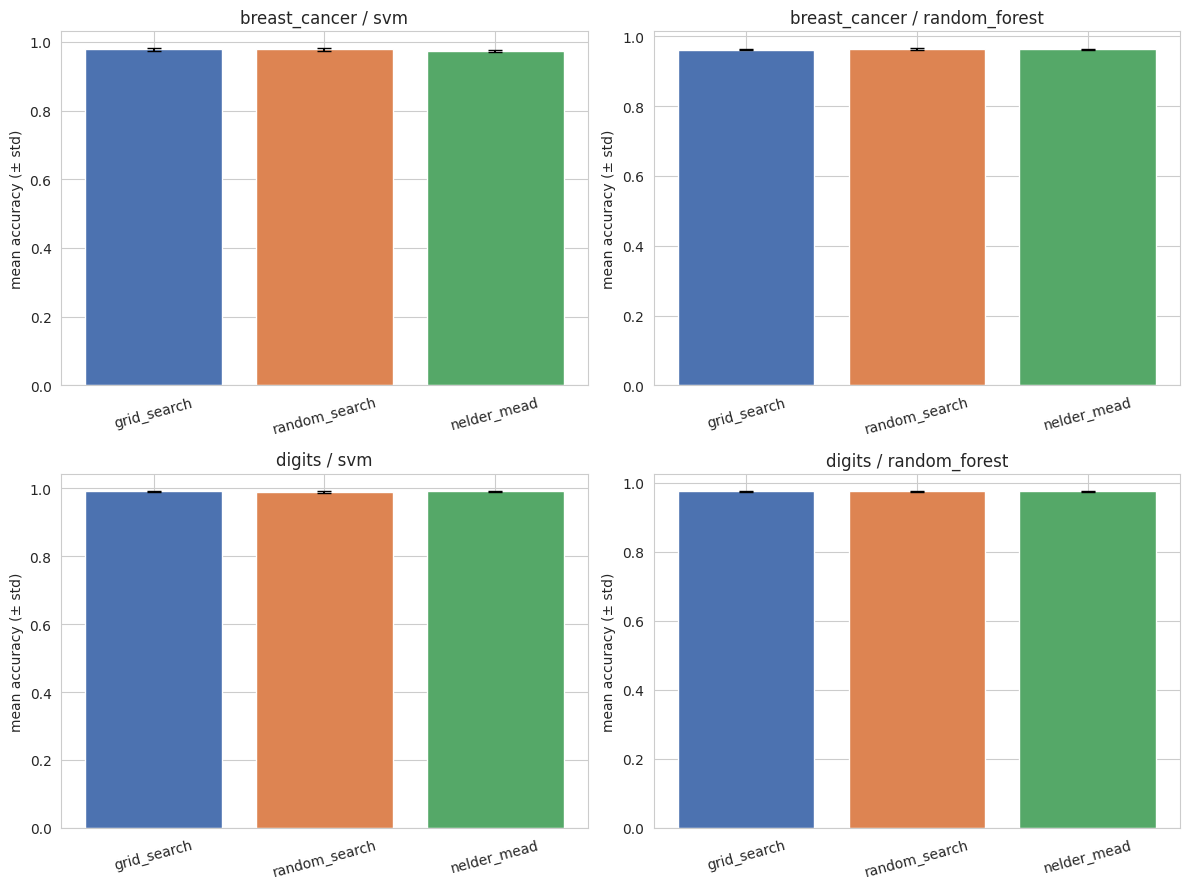

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
kombinacije = rezultati[['dataset', 'model']].drop_duplicates().values

for ax, (ime_skupa, ime_modela) in zip(axes.flat, kombinacije):
    podskup = rezultati[(rezultati['dataset'] == ime_skupa) & (rezultati['model'] == ime_modela)]
    ax.bar(podskup['method'], podskup['mean_score'], yerr=podskup['std_score'],
           capsize=5, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title(f'{ime_skupa} / {ime_modela}')
    ax.set_ylabel('mean accuracy (± std)')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

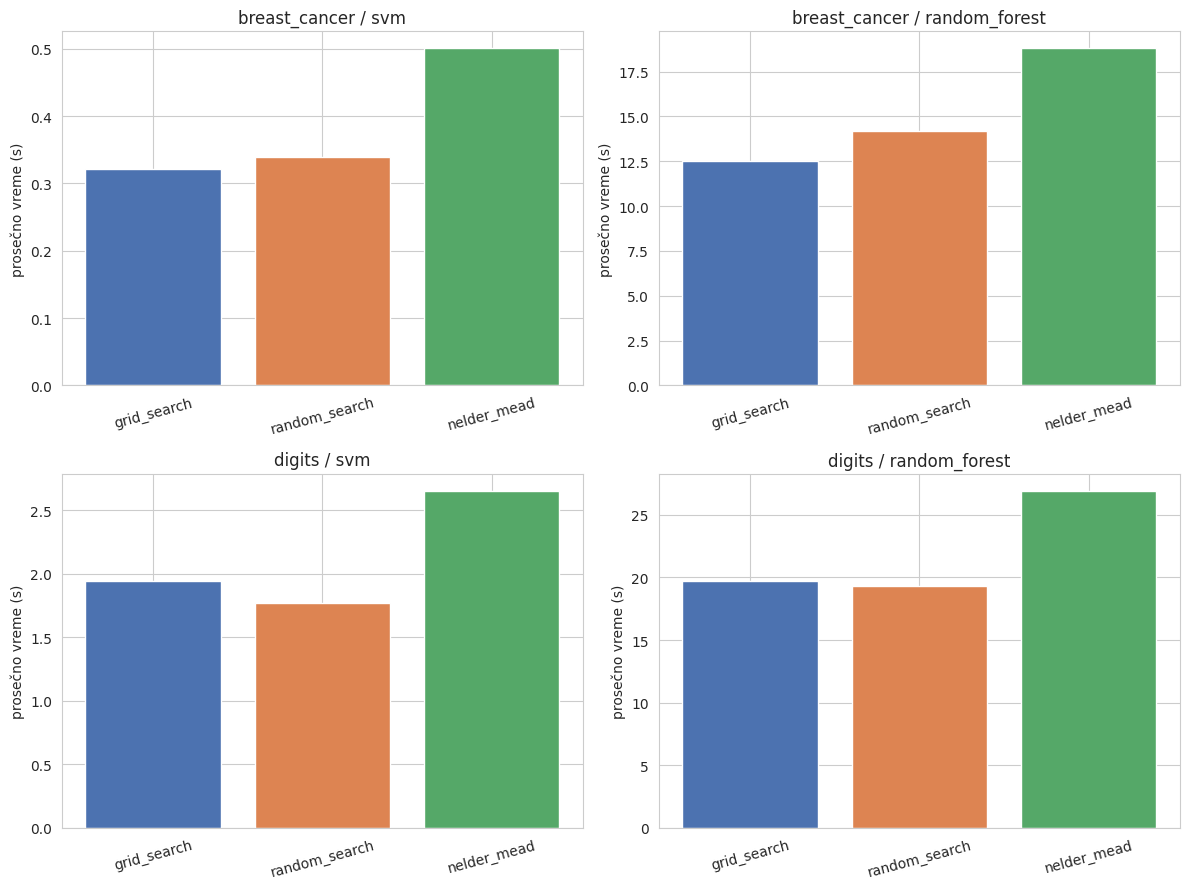

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (ime_skupa, ime_modela) in zip(axes.flat, kombinacije):
    podskup = rezultati[(rezultati['dataset'] == ime_skupa) & (rezultati['model'] == ime_modela)]
    ax.bar(podskup['method'], podskup['mean_time_sec'], color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title(f'{ime_skupa} / {ime_modela}')
    ax.set_ylabel('prosečno vreme (s)')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Najbolja kombinacija

In [21]:
najbolji_red = rezultati.loc[rezultati['mean_score'].idxmax()]
print('Najbolja kombinacija (po prosečnom rezultatu preko 10 seed-ova):')
print(najbolji_red[['dataset', 'model', 'method', 'mean_score', 'std_score']])
print()
print('Reprezentativni hiperparametri (iz najboljeg pojedinačnog pokretanja):')
print(ast.literal_eval(najbolji_red['best_params']))

Najbolja kombinacija (po prosečnom rezultatu preko 10 seed-ova):
dataset            digits
model                 svm
method        nelder_mead
mean_score       0.990884
std_score        0.001827
Name: 10, dtype: object

Reprezentativni hiperparametri (iz najboljeg pojedinačnog pokretanja):
{'C': 0.9968389521625052, 'gamma': 0.0007943282347242919}


## Finalna provera na test skupu

Sve do sada prikazane vrednosti (`mean_score`, `std_score`) su procene dobijene preko unakrsne validacije na trening delu. Da bismo proverili da li te procene zaista odražavaju ponašanje na neviđenim podacima, sada za svaku kombinaciju uzimamo njene reprezentativne hiperparametre, treniramo model na celom trening delu, i evaluiramo ga na test delu, koji nijedna metoda nije videla tokom pretrage.

In [22]:
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

In [23]:
#ista podela kao u ostalim
breast_cancer = load_breast_cancer()
digits = load_digits()

X_bc, y_bc = breast_cancer.data, breast_cancer.target
X_dg, y_dg = digits.data, digits.target

X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)
X_dg_train, X_dg_test, y_dg_train, y_dg_test = train_test_split(
    X_dg, y_dg, test_size=0.2, random_state=42, stratify=y_dg)

skaler_bc = StandardScaler()
X_bc_train = skaler_bc.fit_transform(X_bc_train)
X_bc_test = skaler_bc.transform(X_bc_test)

trening_test_podaci = {
    'breast_cancer': (X_bc_train, y_bc_train, X_bc_test, y_bc_test),
    'digits': (X_dg_train, y_dg_train, X_dg_test, y_dg_test),
}

In [24]:
test_rezultati = []  

for _, red in rezultati.iterrows():
    ime_skupa = red['dataset']
    ime_modela = red['model']
    ime_metode = red['method']
    params = ast.literal_eval(red['best_params'])

    X_train, y_train, X_test, y_test = trening_test_podaci[ime_skupa]

    if ime_modela == 'svm':
        model = SVC(kernel='rbf', random_state=42, **params)
    else:
        model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)

    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))

    test_rezultati.append({
        'dataset': ime_skupa,
        'model': ime_modela,
        'method': ime_metode,
        'cv_mean_score': red['mean_score'],   
        'test_accuracy': test_acc,             
    })

df_test = pd.DataFrame(test_rezultati)
df_test['razlika'] = df_test['test_accuracy'] - df_test['cv_mean_score']
df_test

,dataset,model,method,cv_mean_score,test_accuracy,razlika
0,breast_cancer,svm,grid_search,0.977582,0.982456,0.004874
1,breast_cancer,random_forest,grid_search,0.961971,0.956140,-0.005831
2,digits,svm,grid_search,0.990814,0.988889,-0.001925
3,digits,random_forest,grid_search,0.975017,0.969444,-0.005573
4,breast_cancer,svm,random_search,0.977579,0.964912,-0.012667
5,breast_cancer,random_forest,random_search,0.962851,0.956140,-0.006711
6,digits,svm,random_search,0.989214,0.994444,0.005231
7,digits,random_forest,random_search,0.974530,0.966667,-0.007864
8,breast_cancer,svm,nelder_mead,0.973844,0.982456,0.008612
9,breast_cancer,random_forest,nelder_mead,0.962189,0.956140,-0.006049


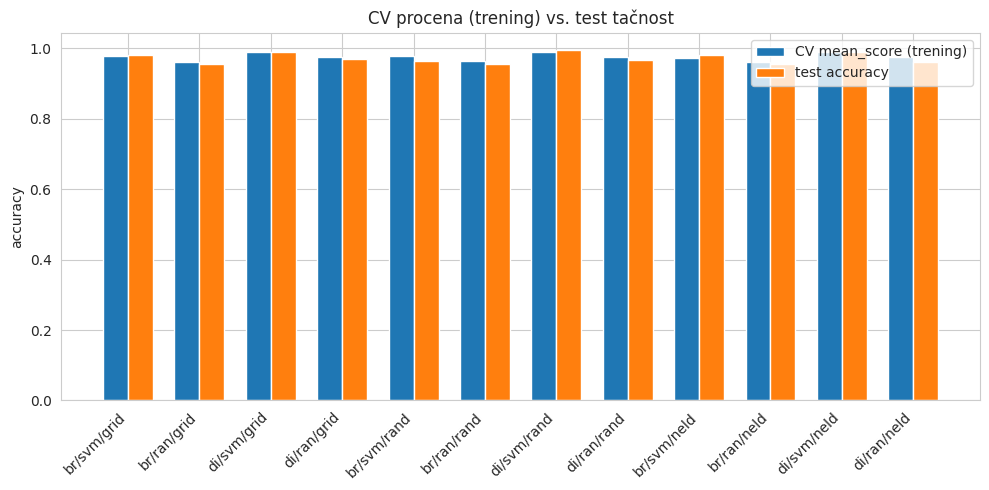

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
x_pozicije = np.arange(len(df_test))
sirina = 0.35

ax.bar(x_pozicije - sirina/2, df_test['cv_mean_score'], sirina, label='CV mean_score (trening)')
ax.bar(x_pozicije + sirina/2, df_test['test_accuracy'], sirina, label='test accuracy')

oznake = df_test['dataset'].str[:2] + '/' + df_test['model'].str[:3] + '/' + df_test['method'].str[:4]
ax.set_xticks(x_pozicije)
ax.set_xticklabels(oznake, rotation=45, ha='right')
ax.set_ylabel('accuracy')
ax.set_title('CV procena (trening) vs. test tačnost')
ax.legend()
plt.tight_layout()
plt.show()

## Matrica konfuzije najbolje kombinacije 

In [26]:
najbolji_test_red = df_test.loc[df_test['test_accuracy'].idxmax()]
print('Najbolja kombinacija na test skupu:')
print(najbolji_test_red)

X_train, y_train, X_test, y_test = trening_test_podaci[najbolji_test_red['dataset']]
izvorni_red = rezultati[
    (rezultati['dataset'] == najbolji_test_red['dataset']) &
    (rezultati['model'] == najbolji_test_red['model']) &
    (rezultati['method'] == najbolji_test_red['method'])
].iloc[0]
params = ast.literal_eval(izvorni_red['best_params'])

if najbolji_test_red['model'] == 'svm':
    finalni_model = SVC(kernel='rbf', random_state=42, **params)
else:
    finalni_model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)

finalni_model.fit(X_train, y_train)

Najbolja kombinacija na test skupu:
dataset                 digits
model                      svm
method           random_search
cv_mean_score         0.989214
test_accuracy         0.994444
razlika               0.005231
Name: 6, dtype: object


SVC(C=24.335817588808077, gamma=0.0002082485125344959, random_state=42)

## Zaključci

**Napomena:** prva verzija ove analize je pokazala nestabilnost Nelder-Mead-a na `breast_cancer/svm` (std=0.153, `mean_score`=0.82). Ovo nije posledica same metode, već posledica tri odvojena problema: (1) nestandardizovanih atributa (RBF SVM je osetljiv na skalu), (2) prevelike osetljivosti `dekoduj_rf` funkcije na zaokruživanje bez odgovarajuće veličine početnog simpleksa, i (3) praga konvergencije (`fatol`). Nakon ispravke sve tri stvari (skaliranje samo za Breast Cancer, eksplicitan `initial_simplex` za Random Forest, `fatol=1e-5`), rezultat je popravljen. - (hvala asistentu na sugestiji).

**Koja metoda daje najbolji `mean_score`, po skupu podataka i po modelu?** Nakon ispravki, razlike između sve tri metode su svuda male i statistički beznačajne (< 0.002 na tri od četiri kombinacije). Grid i Random Search su identični na `breast_cancer/svm` (0.9776 obe), Random Search je neznatno najbolji na `breast_cancer/random_forest` (0.9629), Grid Search na `digits/random_forest` (0.9750), a Nelder-Mead "pobeđuje" na `digits/svm` (0.9909) — ali svega 0.0001-0.002 iznad ostalih, dakle bez stvarne prednosti.

**Da li se `mean_score` (CV) i `test_accuracy` slažu?** Da, dosledno na svih 12 kombinacija — razlike su sada svuda u razumnom opsegu od -0.014 do +0.009, bez ijednog izuzetka ili ekstremnog odstupanja (za razliku od pre ispravke, gde je jedna kombinacija odstupala za +0.112). Ovo potvrđuje da CV procena sada pouzdano predviđa ponašanje na neviđenim podacima, za sve tri metode podjednako.

**Koja metoda ima najmanji `std_score` (najstabilnija)?** Sve tri metode su sada podjednako stabilne na svih 12 kombinacija (std između 0.0015 i 0.0038) — nema više izdvojenog "lošeg" slučaja. Ispravke koje smo primenili (skaliranje, `initial_simplex`, stroži `fatol`) su Nelder-Mead doveli na isti nivo pouzdanosti kao Grid i Random Search.

**Koja metoda daje najbolji odnos kvalitet/vreme?** Ovde je slika sada jasnija: Random Search i Grid Search su uporedivo brzi (Random Search blago brži u 3 od 4 kombinacije), dok je Nelder-Mead dosledno najsporiji u svih 12 kombinacija — razlika je sada i veća nego u prvoj verziji analize, jer su ga ispravke (veći `initial_simplex`, stroži `fatol`) učinile temeljnijim ali i skupljim. Pošto sada nema razlike u kvalitetu rezultata, ovo dodatno vreme se ne isplati. Random Search je najbolji sveukupni izbor za ovaj tip problema.

**SVM naspram Random Forest-a.** Nakon ispravki, oba modela se ponašaju konzistentno na sve tri metode — nema više razlike u ponašanju Nelder-Mead-a između SVM-a i RF-a. Ono što ostaje vidljivo je da RF-ov diskretan prostor čini Nelder-Mead sporijim (veći `initial_simplex` korak i više evaluacija: 65-82 naspram  približno 18-32 kod SVM-a), ali ne i manje pouzdanim — što potvrđuje da je `initial_simplex` popravka uspešno rešila problem.

**Breast Cancer naspram Digits.** Razlike između skupova su sada uglavnom svedene na očekivano: Digits je bolje uslovljen problem (manje varijanse, sve tri metode blizu 0.99 na SVM-u), dok je Breast Cancer osetljiviji na predobradu (skaliranje je ovde napravilo najveću razliku, +0.03 do +0.04 u odnosu na neskalirane rezultate iz prve verzije analize). Random Forest se ponaša slično na oba skupa nezavisno od skaliranja.

**Poređenje sa literaturom (Yang & Shami, 2020).** I dalje se potvrđuje centralni zaključak rada da Grid i Random Search daju međusobno vrlo slične rezultate pri istom broju evaluacija. Ono što naš eksperiment dodaje ovoj slici jeste da Nelder-Mead, kada se pravilno primeni (odgovarajuća predobrada podataka, prilagođen `initial_simplex` za diskretne hiperparametre, dovoljno strog prag konvergencije), dostiže isti kvalitet kao Grid/Random Search — po cenu dužeg vremena izvršavanja usled sekvencijalne prirode algoritma.